# 1. Business Case Discovery

## 1.1 Contexto del Negocio y Antecedentes

Una importante compañía de envíos ha decidido modernizar su sistema de ruteo de correspondencia, paquetes y encomiendas. Actualmente, el proceso de clasificación se realiza de manera semi-automática y con intervención manual, lo que ocasiona demoras y errores en la entrega.
El negocio ha identificado que el reconocimiento automático de los dígitos que componen el código postal en los paquetes puede agilizar el proceso y reducir costos operativos, mejorando la satisfacción del cliente.

## 1.2 Objetivo del Proyecto

El propósito es desarrollar un sistema de reconocimiento de dígitos basado en un modelo de red neuronal convolucional que:
- Identifique correctamente los dígitos del código postal en imágenes de paquetes.
- Automatice el ruteo y la clasificación en función del código postal.

## 1.3 Métricas de Éxito
- Precisión (Accuracy): Porcentaje de dígitos reconocidos correctamente en cada imagen.
- Tiempo de Inferencia: Tiempo requerido para procesar cada imagen, clave para aplicaciones en tiempo real.
- Número de Parámetros: Comparación de la eficiencia del modelo, evaluando la complejidad y capacidad de generalización.

## 1.4 Desafíos y Consideraciones
- Calidad y Variabilidad de las Imágenes: Diferentes condiciones de iluminación, ángulos y ruido pueden dificultar la clasificación.
- Overfitting y Underfitting: Balancear la complejidad del modelo para que no se adapte excesivamente a las muestras de entrenamiento.

# 2. Data Processing

## 2.1 Dataset para Entrenamiento
Para este caso de estudio, utilizaremos el dataset MNIST (Modified National Institute of Standards and Technology), que contiene 70,000 imágenes en escala de grises (28x28 píxeles) de dígitos manuscritos (0-9). Este conjunto de datos es ampliamente utilizado para tareas de clasificación de imágenes y servirá como base para entrenar nuestro modelo de reconocimiento de dígitos en códigos postales.

In [3]:
import tensorflow as tf

(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"Formato de imágenes de entrenamiento: {x_train_full.shape}")
print(f"Formato de etiquetas de entrenamiento: {y_train_full.shape}")
print(f"Formato de imágenes de prueba: {x_test.shape}")

Formato de imágenes de entrenamiento: (60000, 28, 28)
Formato de etiquetas de entrenamiento: (60000,)
Formato de imágenes de prueba: (10000, 28, 28)


## 2.2 Análisis Exploratorio y Visualización

### Visualizar múltiples muestras de dígitos en diferentes formatos

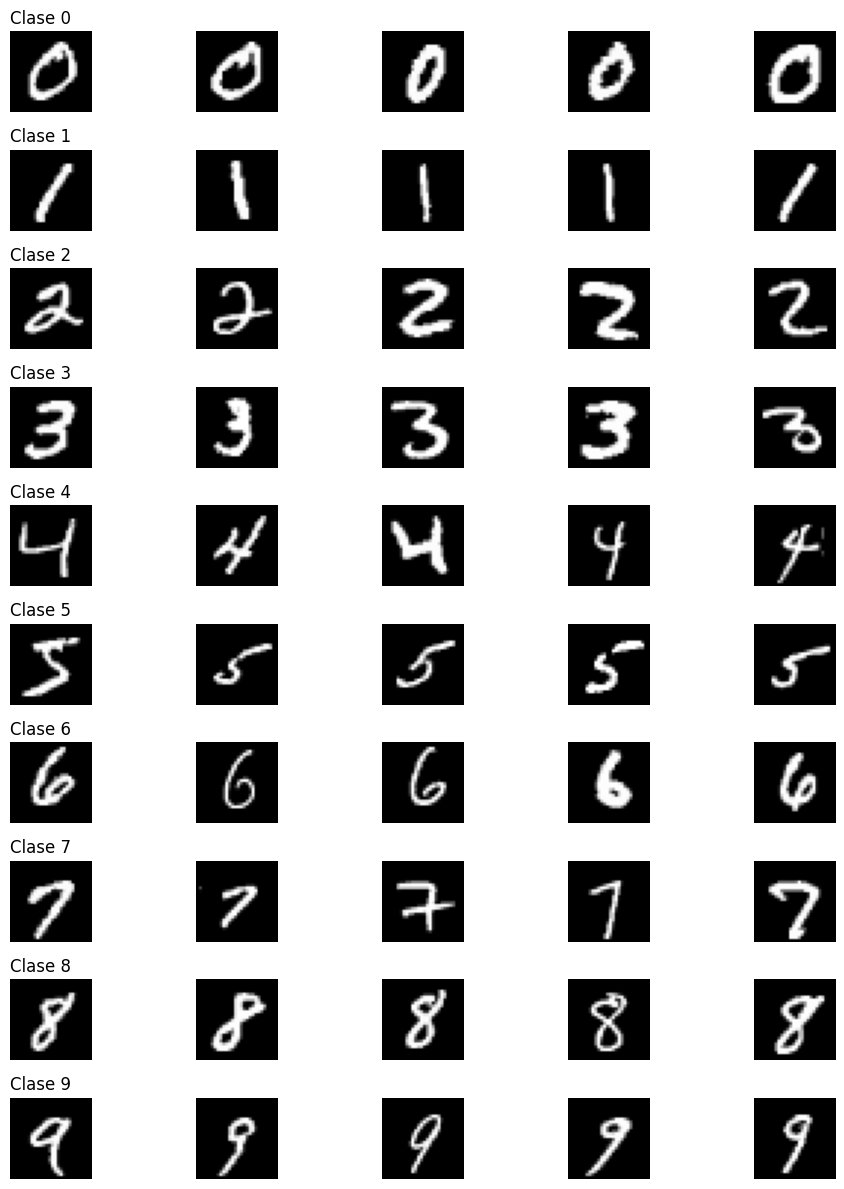

In [4]:
import matplotlib.pyplot as plt
import numpy as np

num_clases = 10
muestras_por_clase = 5

plt.figure(figsize=(10, 12))

for clase in range(num_clases):
    # Encontramos todos los índices correspondientes a la clase actual
    indices = np.where(y_train_full == clase)[0]
    
    for i in range(muestras_por_clase):
        # Calculamos la posición en la cuadrícula (10 filas x 5 columnas)
        plt.subplot(num_clases, muestras_por_clase, clase * muestras_por_clase + i + 1)
        plt.imshow(x_train_full[indices[i]], cmap='gray')
        plt.axis("off")
        
        # Ponemos título solo a la primera columna para identificar la fila
        if i == 0:
            plt.title(f"Clase {clase}", loc='left')

plt.tight_layout()
plt.show()

### Histogramas y Diagramas de Dispersión para el analisis de la distribución de las clases

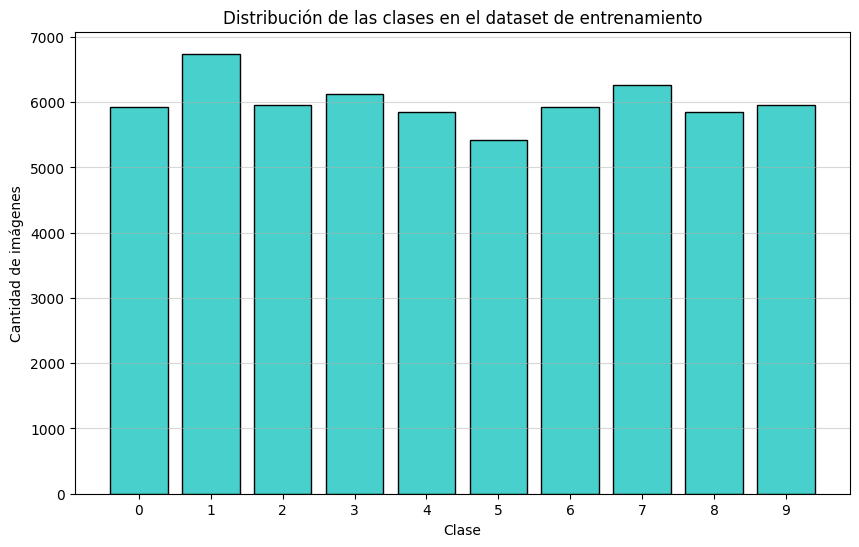

In [5]:
plt.figure(figsize=(10, 6))

# Usamos bins alineados a los números del 0 al 9 para crear el histograma
plt.hist(y_train_full, bins=np.arange(-0.5, 10.5, 1), rwidth=0.8, color='mediumturquoise', edgecolor='black')

plt.xticks(range(10))
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de las clases en el dataset de entrenamiento")
plt.grid(axis='y', alpha=0.5)

plt.show()

Al observar el histograma, se aprecia un ligero desbalance entre el dígito 1, siendo esta la clase mayoritaria, y el dígito 5, la clase minoritaria 

En este caso el desbalance es leve con una diferencia aproximada de un 20% entre la clase mayoritaria y minoritaria, por lo que el modelo debería ser capaz de generalizar sin graves problemas. 

En caso de que este desbalance afectase al rendimiento, aplicaríamos augmentation focalizado transformando (mediante rotaciones leves, zoom...)exclusivamente a las clases minoritarias como el 5, hasta igualar el volumen del resto. Otra alternativa sería aplicar oversampling duplicando las muestras de las clases minoritarias.

### Posibles anomalías o sesgos en la distribución de imágenes

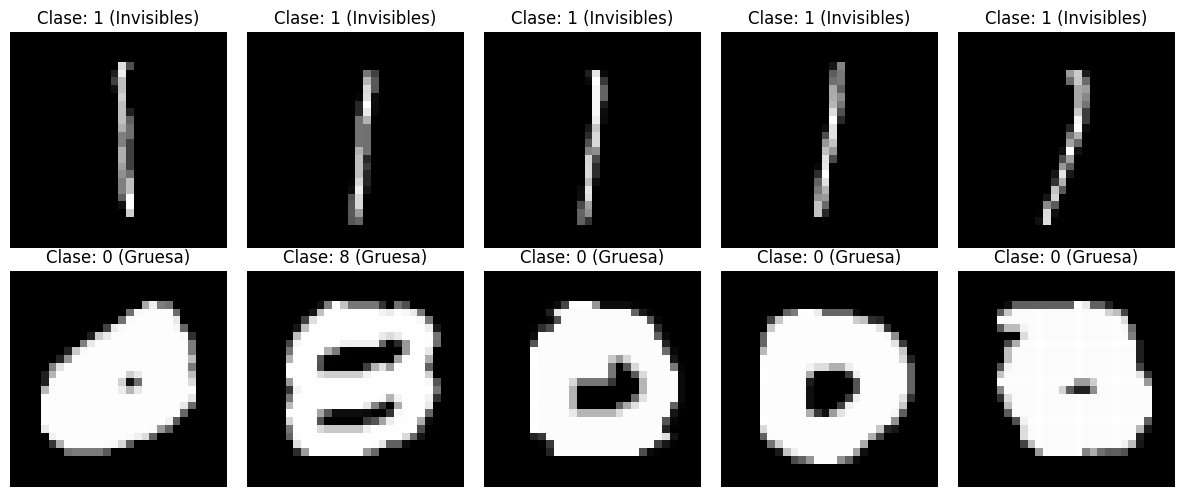

In [6]:
plt.figure(figsize=(12, 5))

# Calculamos la suma de píxeles de cada imagen
intensidad_total = np.sum(x_train_full, axis=(1, 2))

# Obtenemos los índices de las 5 imágenes con menor suma de píxeles y las 5 con mayor suma de píxeles
indices_baja_intensidad = np.argsort(intensidad_total)[:5]
indices_alta_intensidad = np.argsort(intensidad_total)[-5:]

# Imágenes casi invisibles o rotas
for i, idx in enumerate(indices_baja_intensidad):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[idx], cmap='gray')
    plt.title(f"Clase: {y_train_full[idx]} (Invisibles)")
    plt.axis("off")

# Imágenes demasiado gruesas o manchadas
for i, idx in enumerate(indices_alta_intensidad):
    plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_full[idx], cmap='gray')
    plt.title(f"Clase: {y_train_full[idx]} (Gruesa)")
    plt.axis("off")

plt.tight_layout()
plt.show()

1. **Dígitos rotados o mal centrados:** No deben eliminarse ni corregirse, ya que gracias a sus capas de Pooling, la CNN es capaz de aprender cierta invariancia espacial. Además, esto ayudará al modelo a aprender a reconocer estos números torcidos.

2. **Imágenes con ruido o baja calidad:** Se deben mantener, ya que eliminando todas estas imágenes solo quedan números perfectos, por lo que es muy probable que el modelo tenga overfitting. En conclusión, este ruido ayuda al modelo a aprender los numeros mejor, ya que no todo el mundo escribe igual.

3. **Etiquetas incorrectas o imágenes 100% corruptas:** En este caso sí deberían ser eliminadas, ya que generan confusión al modelo en lugar de aportar valor de aprendizaje.

## 2.3 Limpieza y Preprocesamiento de Imágenes

### Redimensionamiento y Normalización

In [7]:
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### Aumento de Datos

In [8]:
from tensorflow.keras import layers
import tensorflow as tf

# Usamos transformaciones muy leves para no dejar los números irreconocibles
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.05, fill_mode="constant"), 
    layers.RandomZoom(height_factor=0.1, width_factor=0.1, fill_mode="constant"),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode="constant")
], name="capa_data_augmentation")

### Conversión de Formatos

In [9]:
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

## 2.4 División de Datos: Entrenamiento, Validación y Test

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

# Unimos todo para tener el dataset completo
x_total = np.concatenate((x_train_full, x_test), axis=0)
y_total = np.concatenate((y_train_full, y_test), axis=0)

# Extraemos el 15% para Test usando stratify para garantizar que la distribución de clases sea idéntica
x_temp, x_test_final, y_temp, y_test_final = train_test_split(
    x_total, y_total, test_size=0.15, random_state=42, stratify=y_total
)

# Del 85% restante extraemos la validación (15% del total)
x_train_final, x_val_final, y_train_final, y_val_final = train_test_split(
    x_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp
)

# Resultados finales
print("--- División Completada ---")
print(f"Entrenamiento (70%): {x_train_final.shape[0]}")
print(f"Validación (15%): {x_val_final.shape[0]}")
print(f"Prueba/Test (15%): {x_test_final.shape[0]}")

--- División Completada ---
Entrenamiento (70%): 49000
Validación (15%): 10500
Prueba/Test (15%): 10500


# 3. Model Planning

## 3.1 Definición del Problema y Enfoque

- **Tipo de Problema:** Clasificación de imágenes, donde cada imagen representa un dígito del 0 al 9.
- **Objetivo:** Lograr una alta precisión en la identificación de dígitos, minimizando errores que puedan afectar el ruteo de paquetes.

## 3.2 Propuesta de trabajo

El objetivo es construir una CNN funcional para clasificación de dígitos y dejarla lista para ser evaluada con el dataset MNIST.

## 3.3 Criterios de entrenamiento

- Preparar correctamente los datos para que tengan la forma adecuada para una CNN.
- Entrenar el modelo con un flujo claro de train/validación/test.
- Monitorizar métricas durante el entrenamiento para detectar sobreajuste o underfitting.

## 3.4 Función de pérdida y evaluación

- **Función de pérdida:** usar entropía cruzada categórica (categorical_crossentropy) o su variante equivalente según la codificación de etiquetas.
- **Evaluación:** medir precisión y loss, y analizar la matriz de confusión y ejemplos de error.

# 4. Model Building and Selection

## 4.1 Construcción y entrenamiento

In [11]:
from tensorflow.keras import layers, models, callbacks

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Añadimos nuestra capa de aumento de datos al inicio
    data_augmentation, 
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 4.2 Validación y análisis

In [12]:
# Espera 5 épocas si no mejora, y restaura los mejores pesos
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# Usamos un batch size de 64 y un máximo de 30 épocas (el early stopping lo frenará antes si es necesario)
print("Iniciando el entrenamiento de la CNN...")

history = model.fit(
    x_train_final, 
    y_train_final,
    epochs=30,
    batch_size=64,
    validation_data=(x_val_final, y_val_final),
    callbacks=[early_stopping]
)

print("¡Entrenamiento finalizado!")

Iniciando el entrenamiento de la CNN...
Epoch 1/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.8379 - loss: 0.5011 - val_accuracy: 0.9722 - val_loss: 0.0836
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9516 - loss: 0.1646 - val_accuracy: 0.9820 - val_loss: 0.0574
Epoch 3/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.9634 - loss: 0.1239 - val_accuracy: 0.9858 - val_loss: 0.0453
Epoch 4/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 70s 42ms/step - accuracy: 0.9704 - loss: 0.1036 - val_accuracy: 0.9865 - val_loss: 0.0419
Epoch 5/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 36s 47ms/step - accuracy: 0.9742 - loss: 0.0874 - val_accuracy: 0.9910 - val_loss: 0.0315
Epoch 6/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.9770 - loss: 0.0796 - val_accuracy: 0.9914 - val_loss: 0.0310
Epoch 7/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.9792 - loss: 0.0732 - val_accuracy: 0.9894 - val_loss: 0.0379
Epoch 8/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 43s 40ms/s

## 4.3 Selección del modelo final

He decidido no continuar itreando para la obtención de un mejor modelo por los siguientes motivos:

- Rendimiento excepcional: El modelo ha alcanzado una precisión del 99.33% en datos de prueba, siendo una tasa de acierto muy elevada, que garantiza una automatización del ruteo casi total.

- Relación Coste-Beneficio: Considerando que el margen de mejora es muy bajo y que la arquitectura actual es estable y fiable, se considera este modelo como óptimo.

# 5. Presentación de Resultados

## 5.1 Análisis Cuantitativo de las Métricas

In [20]:
index_best_epoch = 10 

train_acc = history.history['accuracy'][index_best_epoch]
train_loss = history.history['loss'][index_best_epoch]
val_acc = history.history['val_accuracy'][index_best_epoch]
val_loss = history.history['val_loss'][index_best_epoch]

test_loss, test_acc = model.evaluate(x_test_final, y_test_final, verbose=1)

print(f"\nResultados en Entrenamiento (Train)   | Accuracy: {train_acc:.4f} | Loss: {train_loss:.4f}")
print(f"Resultados en Validación (Validation) | Accuracy: {val_acc:.4f} | Loss: {val_loss:.4f}")
print(f"Resultados en Prueba (Test)           | Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9933 - loss: 0.0285

Resultados en Entrenamiento (Train)   | Accuracy: 0.9844 | Loss: 0.0540
Resultados en Validación (Validation) | Accuracy: 0.9927 | Loss: 0.0264
Resultados en Prueba (Test)           | Accuracy: 0.9933 | Loss: 0.0285


## 5.2 Visualización de Resultados

### Curvas de Entrenamiento y Validación

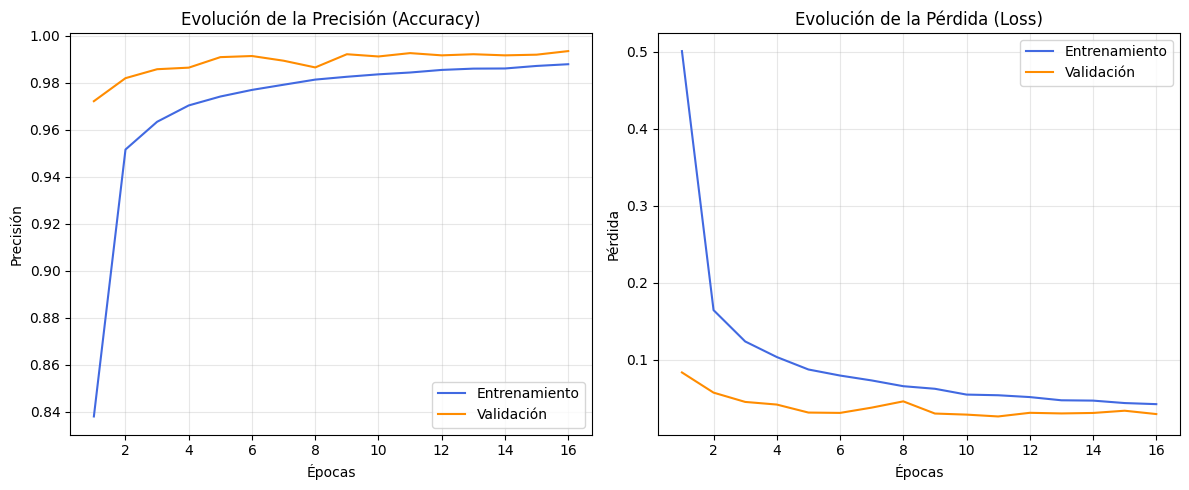

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Extraemos los datos del historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Gráfica de Precisión (Accuracy)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(epochs_range, acc, label='Entrenamiento', color='royalblue')
ax1.plot(epochs_range, val_acc, label='Validación', color='darkorange')
ax1.set_title('Evolución de la Precisión (Accuracy)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Precisión')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# Gráfica de Pérdida (Loss)
ax2 = plt.subplot(1, 2, 2)
ax2.plot(epochs_range, loss, label='Entrenamiento', color='royalblue')
ax2.plot(epochs_range, val_loss, label='Validación', color='darkorange')
ax2.set_title('Evolución de la Pérdida (Loss)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Pérdida')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### Matriz de Confusión

329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


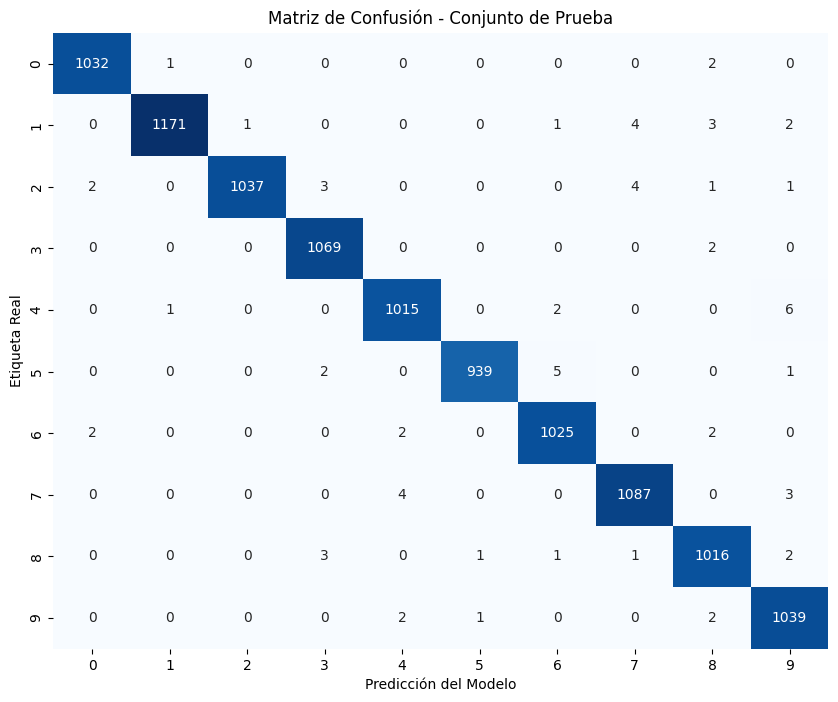

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred_prob = model.predict(x_test_final)
y_pred = np.argmax(y_pred_prob, axis=1)

# Generamos la matriz de confusión
cm = confusion_matrix(y_test_final, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión - Conjunto de Prueba')
plt.show()

### Análisis de Errores

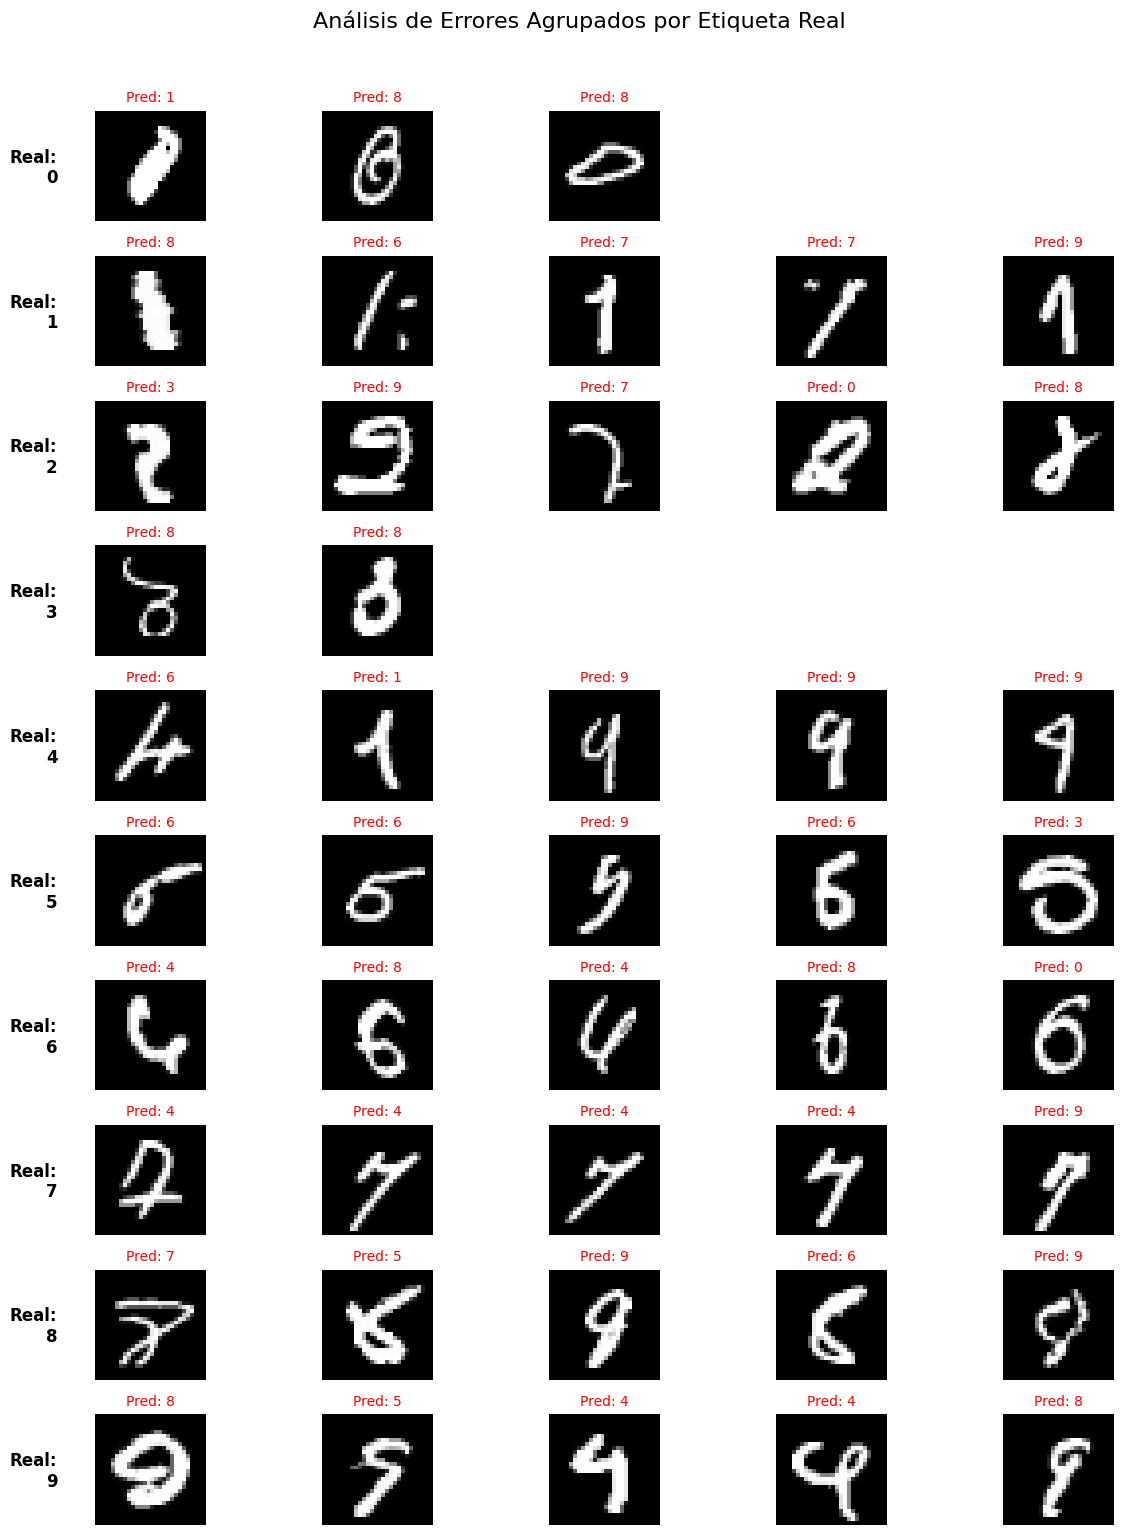

In [23]:
import numpy as np
import matplotlib.pyplot as plt

indices_errores = np.where(y_pred != y_test_final)[0]

plt.figure(figsize=(12, 15))
grafico_actual = 1
ejemplos_por_clase = 5

for clase_real in range(10):
    errores_de_esta_clase = [idx for idx in indices_errores if y_test_final[idx] == clase_real]
    
    for i, idx in enumerate(errores_de_esta_clase[:ejemplos_por_clase]):
        plt.subplot(10, ejemplos_por_clase, grafico_actual)
        plt.imshow(x_test_final[idx].reshape(28, 28), cmap='gray')
        
        plt.title(f"Pred: {y_pred[idx]}", color='red', fontsize=10)
        plt.axis('off')
        
        if i == 0:
            plt.text(-10, 14, f"Real:\n{clase_real}", fontsize=12, fontweight='bold', va='center', ha='right')
            
        grafico_actual += 1
        
    if len(errores_de_esta_clase) < ejemplos_por_clase:
        grafico_actual += (ejemplos_por_clase - len(errores_de_esta_clase))

plt.suptitle('Análisis de Errores Agrupados por Etiqueta Real', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Conclusiones**

Al visualizar ejemplos de imágenes mal clasificadas es evidente que la mayoría de los fallos provienen de la ambigüedad caligráfica.

Observando la cuadrícula de errores agrupados, destacan los siguientes patrones visuales que confunden a la red neuronal:
- El problema del 4 y el 9: Muchos "4"s se han escrito con la parte superior completamente cerrada, lo que visualmente los convierte en un "9".
- El problema del 7 cruzado: En la fila del "7", vemos que cuando la persona le añade una barra horizontal inclinada, la red lo interpreta como un "4".
- Deformaciones severas: Encontramos "2"s trazados con bucles cerrados que los hacen parecer "9"s u "8"s, y un "0" que es literalmente una línea recta inclinada, clasificado lógicamente como un "1".

## 5.3 Comparativa y Reflexión Crítica

**1. Análisis de Generalización y Curvas de Aprendizaje:** 

La curva de validación se mantiene consistentemente mejor o igual que la de entrenamiento, lo que indica que el modelo no presenta overfitting. Lo motivos de una generalización tan buena pueden ser la correcta aplicación de técnicas de regularización, como la capa de Dropout y el Data Augmentation, ya que dificultan la memorización durante el entrenamiento pero permiten que el modelo rinda al máximo al evaluar datos limpios.

**2. Equilibrio entre Precisión y Robustez:**
- Precisión: Lograr un 99.33% de Accuracy en el conjunto de prueba supera con creces los requisitos para la automatización del ruteo de paquetes con seguridad.
- Robustez: Como vimos en el análisis de errores, los escasos fallos del modelo se limitan a caligrafías extremadamente ambiguas o deformadas que resultarían confusas incluso para un humano.

**3. Propuestas de Mejoras Futuras:**
Asumiendo que el modelo actual ya es apto para producción, los siguientes pasos lógicos serían:
- Cuantización del modelo: Reducir el formato de los pesos de float32 a float16 tras el entrenamiento para comprimir más el tamaño del archivo y acelerar la inferencia para desplegarlo directamente en el hardware de los escáneres ópticos de la empresa de envíos.
- Augmentation focalizado: Dado que la matriz de confusión mostró que los errores residuales se concentran en números específicos como el 4 y el 9, se podría aplicar un data augmentation más agresivo exclusivamente a las imágenes de esas clases para forzar a la red a aprender diferencias más sutiles.

# 6. Deployment

## 6.1 Serialización y Almacenamiento del Modelo

In [24]:
import os

nombre_modelo = 'modelo_reconocimiento_postales.keras'
model.save(nombre_modelo)

## 6.2 Desarrollo de una API para Inferencia

Para llevar el modelo a un entorno simulado de producción, se ha desarrollado una interfaz interactiva utilizando el framework Streamlit. Dado que el objetivo del negocio es clasificar el paquete completo, la API no recibe un solo dígito, sino la imagen del código postal entero que en España son 5 dígitos. 

Para resolver esto, se ha implementado la siguiente lógica:

**1. Segmentación de la Imagen mediante OpenCV:** 

La Red Neuronal Convolucional fue entrenada exclusivamente con tensores individuales de forma (28, 28, 1). Para procesar la imagen completa de un código postal, la aplicación aplica un preprocesamiento basado en Visión Artificial tradicional:
   1. Se convierte la imagen a escala de grises y se aplica un umbralizado (Threshold Invertido) para resaltar los trazos.
   2. Mediante el algoritmo cv2.findContours, el sistema detecta los "bloques" de tinta independientes y dibuja cajas delimitadoras (Bounding Boxes) ordenadas de izquierda a derecha.
   3. Cada número recortado se redimensiona a 28x28 píxeles con un relleno de seguridad (padding) y se pasa individualmente por el modelo de Deep Learning para su predicción.
  
**2. Métrica de Confianza:** 

Al calcular la seguridad total del sistema sobre el código postal de 5 dígitos, nos enfrentamos a una decisión de diseño. Matemáticamente, la probabilidad estricta de que todo el código sea correcto equivale a la probabilidad conjunta (el producto de las probabilidades individuales ya que son eventos independientes):

$$P_{total} = P(\text{dígito}_1) \times P(\text{dígito}_2) \times \dots \times P(\text{dígito}_5)$$

Sin embargo, si el modelo tiene un 95% de seguridad en cada uno de los 5 números, el producto probabilístico ($0.95^5$) daría una confianza combinada de apenas el 77%. Mostrar un "77%" a un operario de almacén generaría desconfianza injustificada en el sistema y provocaría revisiones manuales innecesarias.Por tanto, por motivos de Experiencia de Usuario (UX) y operabilidad de negocio, se ha decidido mostrar la Media Aritmética de las confianzas. Lo que ofrece una lectura más intuitiva y estable para el trabajador humano. Como medida de seguridad probabilística, el sistema incluye una alerta interna: si la confianza media cae por debajo del 85%, o un dígito individual es muy dudoso, la aplicación lanza un aviso de "Confianza baja: Verifique manualmene".

**PUEDES VER EL CÓDIGO DE LA APLICACIÓN WEB EN EL FICHERO [app.py](./app.py)**

## 6.3 Pruebas y Validación en Entorno Real

Para comprobar el correcto funcionamiento del pipeline de inferencia (segmentación + predicción) en un entorno real, se ha grabado una demostración en vídeo del sistema procesando un código postal escrito a mano mediante `Paint`.

🎥 [Vídeo de demostración de la Aplicación Web](https://tajamar365-my.sharepoint.com/:v:/p/angel_toledo/IQDzcgU1cHyyRL8rT12efihrAUJT3PW4c2OUT2N_pl6ePMQ?nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJPbmVEcml2ZUZvckJ1c2luZXNzIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXciLCJyZWZlcnJhbFZpZXciOiJNeUZpbGVzTGlua0NvcHkifX0&e=ONIN9g)

# Conclusiones

**1. Importancia crítica del Preprocesamiento:**

Una CNN además de ser sensible a la forma de las imagenes es muy sensible al formato matemático de los datos. No basta con cambiar la forma de la imagen a tensores de (28, 28, 1). Es necesario además convertir las matrices de píxeles a formato de coma flotante `float32` antes de dividirlas por 255.0. Si este paso se omite o se intenta calcular usando enteros (int), la red ajustaría los pesos con una mayor imprecisión ajustando pesos muy elevados. Además se elige `float32` en lugar del `float64` de python para optimizar el rendimiento, ya que require menor rendimiento para el ordenador que el de 64 bits y mantiene una buena precisión para el aprendizaje del modelo.

**2. El comportamiento paradójico del Dropout:**

Observamos en las gráficas que la precisión de validación es superior a la de entrenamiento. Lo que demuestra que realmente la capa de Dropout suge efecto. Durante el entrenamiento, se apagan aleatoriamente el 50% de las neuronas, cegando parcialmente a la red y dificultando su aprendizaje para forzarla a buscar patrones redundantes. Sin embargo, en la fase de evaluación, el Dropout se desactiva y el modelo opera al 100% de su capacidad, resolviendo el problema sin muchas dificultades.

**3. La convivencia entre Visión Clásica y Deep Learning:**

Para resolver el problema de leer 5 números de golpe, descubrimos que la Inteligencia Artificial moderna por sí sola no bastaba. Además necesitábamos integrarla con algoritmos de Visión Artificial tradicional (con OpenCV) para crear un puente entre la imagen cruda y la red neuronal.

**4. El impacto de la variabilidad:**

Introducir giros y desplazamientos aleatorios en las imágenes de entrenamiento hace que el modelo tarde más en converger durante el entrenamiento, pero es clave para erradicar el sobreajuste. Eseñarle imagenes ligeramente deformadas "inmuniza" a la red contra la mala caligrafía humana.

**5. Matemáticas puras vs. Lógica de Negocio:**

Durante el diseño de la API, aprendimos que la corrección estadística no siempre es la mejor solución funcional. Aunque probabilísticamente la seguridad de un código postal completo deba calcularse multiplicando sus probabilidades individuales, aplicar esto daría como resultado porcentajes engañosamente bajos que asustarían al usuario. Por lo que se decidió usar la media aritmétrica para adaptarlo al usuario.